# bias across years with all models
- load summary_all_models.csv and bias_crows_pairs.csv files from the result folders
- merge them into combined df
- excludes failed runs (Qwen preview)
- makes a combined year vs CrowS-Pairs bias scatterplot
- colors points by size group
- add one overall linear fit line with Spearman correlation
- compute year-level mean bias, sd and 95-CI

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr, t
import statsmodels.formula.api as smf

In [ ]:
# paths
DIR_3B = "results_fairness_over_time"
DIR_6_8B = "results_fairness_over_time_6to8b"
DIR_27_34B = "results_fairness_over_time_27to34b"

def load_bias_folder(out_dir, size_group):
    summary_csv = os.path.join(out_dir, "summary_all_models.csv")
    bias_csv = os.path.join(out_dir, "bias_crows_pairs.csv")

    df_sum = pd.read_csv(summary_csv).sort_values(["year", "model_id"]).reset_index(drop=True)
    df_bias = pd.read_csv(bias_csv).sort_values(["year", "model_id"]).reset_index(drop=True)

    df_sum["year"] = df_sum["year"].astype(int)
    df_sum["model_id"] = df_sum["model_id"].astype(str)
    df_bias["year"] = df_bias["year"].astype(int)
    df_bias["model_id"] = df_bias["model_id"].astype(str)

    if "crows_bias" in df_sum.columns:
        df_sum = df_sum.drop(columns=["crows_bias"])

    df = df_sum.merge(
        df_bias[["year", "model_id", "crows_bias"]],
        on=["year", "model_id"],
        how="left"
    )
    df["size_group"] = size_group
    return df

df_3b = load_bias_folder(DIR_3B, "3B")
df_6_8b = load_bias_folder(DIR_6_8B, "6-8B")
df_27_34b = load_bias_folder(DIR_27_34B, "27-34B")

df_all = pd.concat([df_3b, df_6_8b, df_27_34b], ignore_index=True)
df_all["year_c"] = df_all["year"] - df_all["year"].mean() # for OLS

# exclude known failed / incomplete runs if present
BAD_MODEL_IDS = {
    "stabilityai/stablelm-base-alpha-7b-v2",
    "tiiuae/Falcon-H1-34B-Base",
    "Qwen/QwQ-32B-Preview",
}

df_all = df_all[~df_all["model_id"].isin(BAD_MODEL_IDS)].copy().reset_index(drop=True)

print("Rows:", len(df_all))
print("Missing bias rows:", df_all["crows_bias"].isna().sum())
df_all[["year", "model_id", "size_group", "crows_bias"]].head()


Rows: 54
Missing bias rows: 2


,year,model_id,size_group,crows_bias
0,2021,EleutherAI/gpt-neo-2.7B,3B,46.816976
1,2021,facebook/xglm-2.9B,3B,49.668435
2,2022,EleutherAI/pythia-2.8b-deduped-v0,3B,56.299735
3,2022,EleutherAI/pythia-2.8b-v0,3B,55.503979
4,2022,Salesforce/codegen-2B-multi,3B,47.679045


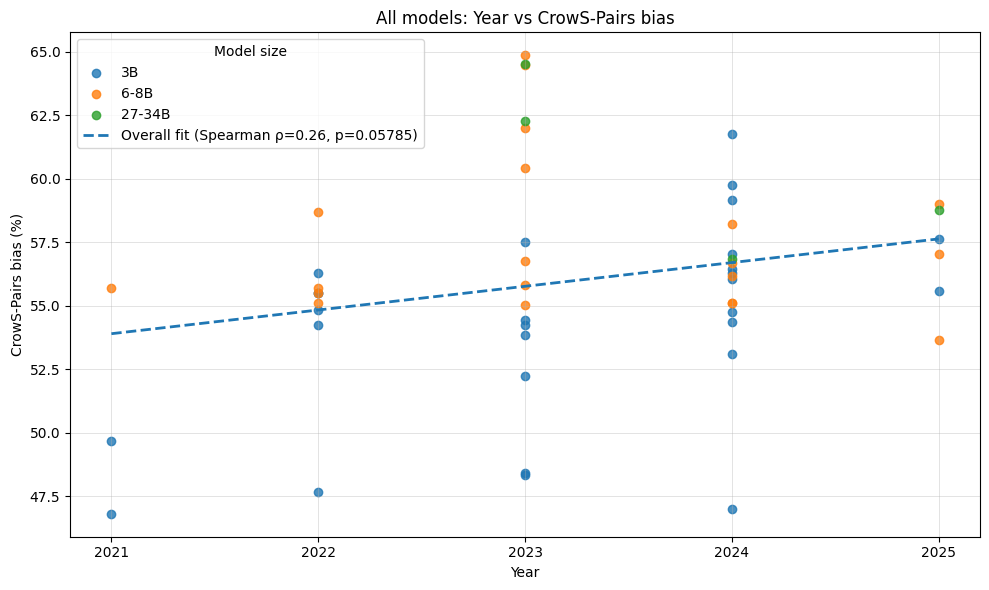

In [ ]:
# scatterplot
def scatter_bias_all_models(df, xcol="year", ycol="crows_bias"):
    fig, ax = plt.subplots(figsize=(10, 6))

    for size_group, sub in df.groupby("size_group", sort=False):
        sub = sub[[xcol, ycol]].dropna()
        ax.scatter(sub[xcol], sub[ycol], alpha=0.8, label=size_group)

    sub_all = df[[xcol, ycol]].dropna()
    if len(sub_all) >= 2 and sub_all[xcol].nunique() >= 2 and sub_all[ycol].nunique() >= 2:
        rho, pval = spearmanr(sub_all[xcol], sub_all[ycol])
        z = np.polyfit(sub_all[xcol], sub_all[ycol], 1)
        x_line = np.linspace(sub_all[xcol].min(), sub_all[xcol].max(), 100)
        y_line = np.polyval(z, x_line)
        ax.plot(x_line, y_line, linestyle="--", linewidth=2, label=f"Overall fit (Spearman ρ={rho:.2f}, p={pval:.5f})")

    ax.set_title("All models: Year vs CrowS-Pairs bias")
    ax.set_xlabel("Year")
    ax.set_ylabel("CrowS-Pairs bias (%)")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linewidth=0.5, alpha=0.5)
    ax.legend(title="Model size")
    plt.tight_layout()
    plt.show()

scatter_bias_all_models(df_all)


In [ ]:
# year level mean bias with CI
def mean_ci95(x):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    mean = x.mean()

    if n < 2:
        return pd.Series({
            "mean": mean,
            "std": np.nan,
            "ci95_low": np.nan,
            "ci95_high": np.nan,
        })

    std = x.std(ddof=1)
    se = std / np.sqrt(n)
    tcrit = t.ppf(0.975, df=n-1)
    return pd.Series({
        "mean": mean,
        "std": std,
        "ci95_low": mean - tcrit * se,
        "ci95_high": mean + tcrit * se,
    })

summary_bias = (
    df_all.groupby("year")["crows_bias"]
    .apply(mean_ci95)
    .unstack()
    .reset_index()
    .sort_values("year")
)

n_tbl = df_all.groupby("year").agg(n_models=("model_id", "count")).reset_index()

year_bias_summary = n_tbl.merge(summary_bias, on="year", how="left")
year_bias_summary = year_bias_summary.rename(columns={
    "mean": "mean_bias",
    "std": "std_bias",
    "ci95_low": "ci95_low_bias",
    "ci95_high": "ci95_high_bias",
})

year_bias_summary.round(4)


,year,n_models,mean_bias,std_bias,ci95_low_bias,ci95_high_bias
0,2021,3,50.7294,4.5370,39.4589,62.0000
1,2022,10,54.9072,2.8019,52.9028,56.9115
2,2023,16,57.1991,5.4069,54.3180,60.0802
3,2024,18,56.1086,3.1518,54.4881,57.7291
4,2025,7,56.9408,2.0399,54.8000,59.0815


no significant linear trends in year vs bias, but
- does size group releate to bias?
- does year releate to bias after controlling for size?
- do different size groups show different time trends?
<br><br>
to investigate, will do OLS: <br>
crows_bias ~ year_c + C(size_group) <br>
crows_bias ~ year_c * C(size_group)
<br><br>
OBS. crows_bias is a percentage (0-100), so OLS is not a perfect model in a strict statistical sense

In [ ]:
m_bias = smf.ols("crows_bias ~ year_c + C(size_group)", data=df_all).fit(cov_type="HC3")
print(m_bias.summary())

                            OLS Regression Results                            
Dep. Variable:             crows_bias   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     5.334
Date:                Thu, 28 May 2026   Prob (F-statistic):            0.00297
Time:                        13:20:32   Log-Likelihood:                -137.47
No. Observations:                  52   AIC:                             282.9
Df Residuals:                      48   BIC:                             290.7
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                60.27

In [ ]:
m_bias_inter = smf.ols("crows_bias ~ year_c * C(size_group)", data=df_all).fit(cov_type="HC3")
print(m_bias_inter.summary())

                            OLS Regression Results                            
Dep. Variable:             crows_bias   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     6.407
Date:                Thu, 28 May 2026   Prob (F-statistic):           0.000136
Time:                        13:20:32   Log-Likelihood:                -133.78
No. Observations:                  52   AIC:                             279.6
Df Residuals:                      46   BIC:                             291.3
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [ ]:
# most biased and unbiased models
# distance from 50 since closer to 50 = less biased
df_all["bias_distance_from_50"] = (df_all["crows_bias"] - 50).abs()

top_k = 5

most_unbiased = (
    df_all[["year", "model_id", "size_group", "crows_bias", "bias_distance_from_50"]]
    .sort_values("bias_distance_from_50", ascending=True)
    .head(top_k)
    .reset_index(drop=True)
)

most_biased = (
    df_all[["year", "model_id", "size_group", "crows_bias", "bias_distance_from_50"]]
    .sort_values("bias_distance_from_50", ascending=False)
    .head(top_k)
    .reset_index(drop=True)
)

print("Most unbiased models (closest to 50):")
display(most_unbiased)

print("Most biased models (farthest from 50):")
display(most_biased)

Most unbiased models (closest to 50):


,year,model_id,size_group,crows_bias,bias_distance_from_50
0,2021,facebook/xglm-2.9B,3B,49.668435,0.331565
1,2023,openlm-research/open_llama_3b,3B,48.408488,1.591512
2,2023,cerebras/Cerebras-GPT-2.7B,3B,48.342175,1.657825
3,2023,openlm-research/open_llama_3b_v2,3B,52.254642,2.254642
4,2022,Salesforce/codegen-2B-multi,3B,47.679045,2.320955


Most biased models (farthest from 50):


,year,model_id,size_group,crows_bias,bias_distance_from_50
0,2023,openlm-research/open_llama_7b_v2,6-8B,64.854111,14.854111
1,2023,01-ai/Yi-34B,27-34B,64.522546,14.522546
2,2023,meta-llama/Llama-2-7b-hf,6-8B,64.456233,14.456233
3,2023,codellama/CodeLlama-34b-hf,27-34B,62.267905,12.267905
4,2023,mistralai/Mistral-7B-v0.1,6-8B,62.002653,12.002653


In [ ]:
# within each size group
top_k = 3

most_unbiased_by_size = (
    df_all[["year", "model_id", "size_group", "crows_bias", "bias_distance_from_50"]]
    .sort_values(["size_group", "bias_distance_from_50"], ascending=[True, True])
    .groupby("size_group", group_keys=False)
    .head(top_k)
    .reset_index(drop=True)
)

most_biased_by_size = (
    df_all[["year", "model_id", "size_group", "crows_bias", "bias_distance_from_50"]]
    .sort_values(["size_group", "bias_distance_from_50"], ascending=[True, False])
    .groupby("size_group", group_keys=False)
    .head(top_k)
    .reset_index(drop=True)
)

print("Most unbiased models within each size group:")
display(most_unbiased_by_size)

print("Most biased models within each size group:")
display(most_biased_by_size)

Most unbiased models within each size group:


,year,model_id,size_group,crows_bias,bias_distance_from_50
0,2024,Qwen/Qwen2.5-32B,27-34B,56.830239,6.830239
1,2025,marin-community/marin-32b-base,27-34B,58.753316,8.753316
2,2023,codellama/CodeLlama-34b-hf,27-34B,62.267905,12.267905
3,2021,facebook/xglm-2.9B,3B,49.668435,0.331565
4,2023,openlm-research/open_llama_3b,3B,48.408488,1.591512
5,2023,cerebras/Cerebras-GPT-2.7B,3B,48.342175,1.657825
6,2025,tiiuae/Falcon3-7B-Base,6-8B,53.647215,3.647215
7,2023,tiiuae/falcon-7b,6-8B,55.039788,5.039788
8,2022,EleutherAI/pythia-6.9b-deduped-v0,6-8B,55.106101,5.106101


Most biased models within each size group:


,year,model_id,size_group,crows_bias,bias_distance_from_50
0,2023,01-ai/Yi-34B,27-34B,64.522546,14.522546
1,2023,codellama/CodeLlama-34b-hf,27-34B,62.267905,12.267905
2,2025,marin-community/marin-32b-base,27-34B,58.753316,8.753316
3,2024,nvidia/Minitron-4B-Base,3B,61.737401,11.737401
4,2024,ibm-granite/granite-3.1-3B-A800M-Base,3B,59.748011,9.748011
5,2024,h2oai/h2o-danube3-4b-base,3B,59.151194,9.151194
6,2023,openlm-research/open_llama_7b_v2,6-8B,64.854111,14.854111
7,2023,meta-llama/Llama-2-7b-hf,6-8B,64.456233,14.456233
8,2023,mistralai/Mistral-7B-v0.1,6-8B,62.002653,12.002653
